
🚀 Entrenando variantes del modelo XGBoost...

🚀 Entrenando variantes del modelo RandomForest...

🚀 Entrenando variantes del modelo MLP...


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(



📊 Resultados comparativos:


,Modelo,Parámetros,Accuracy,Precision,Recall,F1,ROC-AUC
0,XGBoost,"{'learning_rate': 0.05, 'max_depth': 3}",0.879965,0.815468,0.808883,0.812162,0.912754
6,MLP,"{'hidden_layer_sizes': (50, 25), 'activation':...",0.877807,0.819444,0.794078,0.806562,0.912494
1,XGBoost,"{'learning_rate': 0.1, 'max_depth': 4}",0.881261,0.825000,0.799462,0.812030,0.911458
3,RandomForest,"{'n_estimators': 150, 'max_depth': 10, 'criter...",0.878670,0.819945,0.796770,0.808191,0.911204
7,MLP,"{'hidden_layer_sizes': (100, 50), 'activation'...",0.877375,0.820979,0.790040,0.805213,0.910156
5,RandomForest,"{'n_estimators': 250, 'max_depth': None, 'crit...",0.873057,0.813986,0.783311,0.798354,0.908924
4,RandomForest,"{'n_estimators': 200, 'max_depth': 15, 'criter...",0.872193,0.809986,0.786003,0.797814,0.908722
2,XGBoost,"{'learning_rate': 0.2, 'max_depth': 6}",0.870898,0.796791,0.802153,0.799463,0.905220
8,MLP,"{'hidden_layer_sizes': (150, 100, 50), 'activa...",0.863558,0.777633,0.804845,0.791005,0.894202


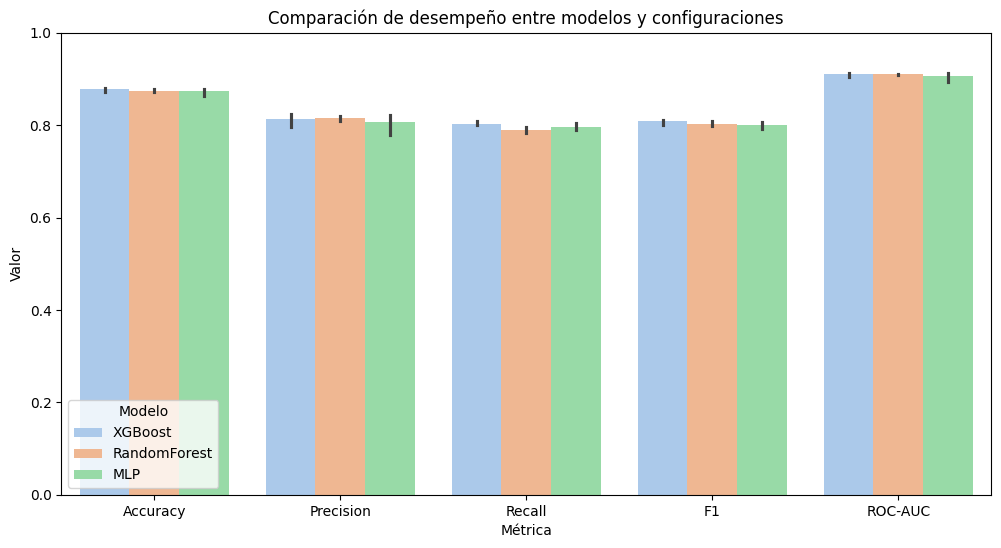


🏆 Mejores configuraciones por modelo:


,Modelo,Parámetros,Accuracy,Precision,Recall,F1,ROC-AUC
0,MLP,"{'hidden_layer_sizes': (50, 25), 'activation':...",0.877807,0.819444,0.794078,0.806562,0.912494
1,RandomForest,"{'n_estimators': 150, 'max_depth': 10, 'criter...",0.878670,0.819945,0.796770,0.808191,0.911204
2,XGBoost,"{'learning_rate': 0.05, 'max_depth': 3}",0.879965,0.815468,0.808883,0.812162,0.912754


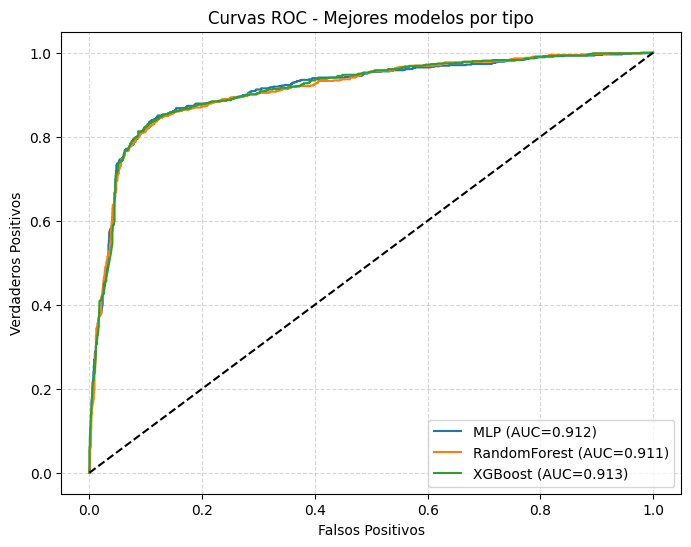


🏁 Ranking Final de Modelos (mejor configuración por tipo):


,Modelo,Parámetros,Accuracy,Precision,Recall,F1,ROC-AUC,Puntaje_Final
0,XGBoost,"{'learning_rate': 0.05, 'max_depth': 3}",0.879965,0.815468,0.808883,0.812162,0.912754,0.849237
1,RandomForest,"{'n_estimators': 150, 'max_depth': 10, 'criter...",0.878670,0.819945,0.796770,0.808191,0.911204,0.846480
2,MLP,"{'hidden_layer_sizes': (50, 25), 'activation':...",0.877807,0.819444,0.794078,0.806562,0.912494,0.845639


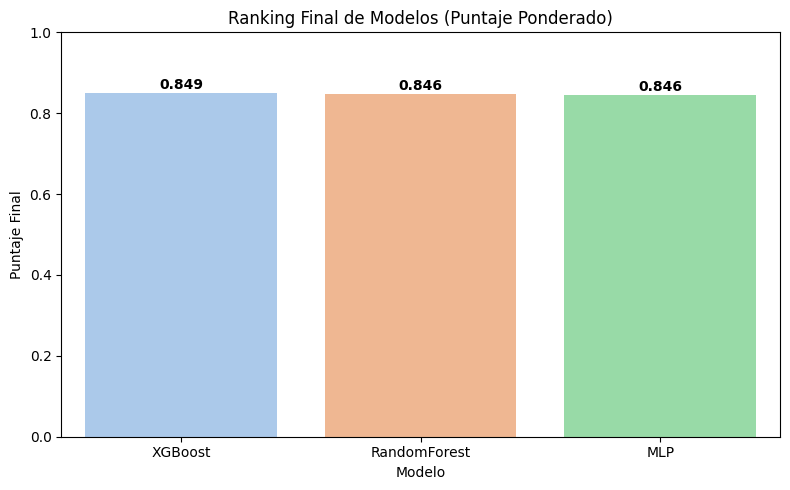

In [10]:
# ==============================================================
# 🔹 1. Importar librerías
# ==============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve
)

from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier

# ==============================================================
# 🔹 2. Cargar y preparar datos
# ==============================================================
df = pd.read_excel("base_para_ml.xlsx")

features = [
    'CALCULO1_NORMALIZADO', 'ECUACIONES_NORMALIZADO',
    'ESTADISTICA_NORMALIZADO', 'FÍSICA1_NORMALIZADO',
    'ALGEBRA_LINEAL_NORMALIZADO'
]
target = 'DESERTOR'

# Extraer año de cohorte
df['COHORTE'] = df['COHORTE'].astype(str)
df['AÑO_COHORTE'] = df['COHORTE'].str[:4].astype(int)

# Dividir datasets
train_df = df[df['AÑO_COHORTE'] <= 2018].dropna(subset=features + [target])
test_df = df[(df['AÑO_COHORTE'] >= 2019) & (df['AÑO_COHORTE'] <= 2022)].dropna(subset=features)

X_train = train_df[features]
y_train = train_df[target]
X_test = test_df[features]
y_test = test_df[target] if target in test_df.columns else None

# Escalar solo para MLP
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ==============================================================
# 🔹 3. Definir configuraciones de modelos
# ==============================================================
configuraciones = {
    "XGBoost": [
        {"learning_rate": 0.05, "max_depth": 3},
        {"learning_rate": 0.1, "max_depth": 4},
        {"learning_rate": 0.2, "max_depth": 6}
    ],
    "RandomForest": [
        {"n_estimators": 150, "max_depth": 10, "criterion": "gini"},
        {"n_estimators": 200, "max_depth": 15, "criterion": "gini"},
        {"n_estimators": 250, "max_depth": None, "criterion": "entropy"}
    ],
    "MLP": [
        {"hidden_layer_sizes": (50, 25), "activation": "relu"},
        {"hidden_layer_sizes": (100, 50), "activation": "relu"},
        {"hidden_layer_sizes": (150, 100, 50), "activation": "tanh"}
    ]
}

# ==============================================================
# 🔹 4. Entrenar y evaluar modelos
# ==============================================================
resultados = []
curvas_roc = {}  # Para guardar las curvas de los mejores modelos

for modelo_nombre, variantes in configuraciones.items():
    print(f"\n🚀 Entrenando variantes del modelo {modelo_nombre}...")

    for params in variantes:
        # Inicializar modelo según tipo
        if modelo_nombre == "XGBoost":
            modelo = XGBClassifier(
                objective='binary:logistic',
                eval_metric='logloss',
                random_state=42,
                n_estimators=150,
                **params
            )
            modelo.fit(X_train, y_train)
            y_pred = modelo.predict(X_test)
            y_proba = modelo.predict_proba(X_test)[:, 1]

        elif modelo_nombre == "RandomForest":
            modelo = RandomForestClassifier(random_state=42, **params)
            modelo.fit(X_train, y_train)
            y_pred = modelo.predict(X_test)
            y_proba = modelo.predict_proba(X_test)[:, 1]

        else:  # MLP
            modelo = MLPClassifier(
                solver='adam',
                max_iter=300,
                random_state=42,
                **params
            )
            modelo.fit(X_train_scaled, y_train)
            y_pred = modelo.predict(X_test_scaled)
            y_proba = modelo.predict_proba(X_test_scaled)[:, 1]

        # Calcular métricas
        acc = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred)
        rec = recall_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        roc = roc_auc_score(y_test, y_proba)

        resultados.append({
            "Modelo": modelo_nombre,
            "Parámetros": str(params),
            "Accuracy": acc,
            "Precision": prec,
            "Recall": rec,
            "F1": f1,
            "ROC-AUC": roc
        })

# ==============================================================
# 🔹 5. Comparar resultados
# ==============================================================
resultados_df = pd.DataFrame(resultados)
print("\n📊 Resultados comparativos:")
display(resultados_df.sort_values(by="ROC-AUC", ascending=False))

# ==============================================================
# 🔹 6. Visualización general
# ==============================================================
plt.figure(figsize=(12, 6))
resultados_melt = resultados_df.melt(id_vars=["Modelo", "Parámetros"],
                                     var_name="Métrica", value_name="Valor")
sns.barplot(data=resultados_melt, x="Métrica", y="Valor", hue="Modelo", palette="pastel")
plt.title("Comparación de desempeño entre modelos y configuraciones")
plt.ylim(0, 1)
plt.legend(title="Modelo")
plt.show()

# ==============================================================
# 🔹 7. Seleccionar los mejores modelos por tipo
# ==============================================================
mejores = resultados_df.loc[resultados_df.groupby("Modelo")["ROC-AUC"].idxmax()].reset_index(drop=True)
print("\n🏆 Mejores configuraciones por modelo:")
display(mejores)

# ==============================================================
# 🔹 8. Graficar curvas ROC de los tres mejores modelos
# ==============================================================
plt.figure(figsize=(8, 6))
for i, fila in mejores.iterrows():
    modelo_nombre = fila["Modelo"]
    params = eval(fila["Parámetros"])

    if modelo_nombre == "XGBoost":
        modelo = XGBClassifier(
            objective='binary:logistic',
            eval_metric='logloss',
            random_state=42,
            n_estimators=150,
            **params
        )
        modelo.fit(X_train, y_train)
        y_proba = modelo.predict_proba(X_test)[:, 1]

    elif modelo_nombre == "RandomForest":
        modelo = RandomForestClassifier(random_state=42, **params)
        modelo.fit(X_train, y_train)
        y_proba = modelo.predict_proba(X_test)[:, 1]

    else:  # MLP
        modelo = MLPClassifier(
            solver='adam',
            max_iter=300,
            random_state=42,
            **params
        )
        modelo.fit(X_train_scaled, y_train)
        y_proba = modelo.predict_proba(X_test_scaled)[:, 1]

    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, label=f"{modelo_nombre} (AUC={auc:.3f})")

plt.plot([0, 1], [0, 1], 'k--')
plt.title("Curvas ROC - Mejores modelos por tipo")
plt.xlabel("Falsos Positivos")
plt.ylabel("Verdaderos Positivos")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# ==============================================================
# 🔹 9. Ranking final de los tres mejores modelos
# ==============================================================

# Definir pesos para cada métrica (puedes ajustarlos)
pesos = {
    "Accuracy": 0.25,
    "Precision": 0.2,
    "Recall": 0.2,
    "F1": 0.15,
    "ROC-AUC": 0.2
}

# Calcular el puntaje ponderado
mejores["Puntaje_Final"] = (
    mejores["Accuracy"] * pesos["Accuracy"] +
    mejores["Precision"] * pesos["Precision"] +
    mejores["Recall"] * pesos["Recall"] +
    mejores["F1"] * pesos["F1"] +
    mejores["ROC-AUC"] * pesos["ROC-AUC"]
)

# Ordenar por puntaje total
ranking_final = mejores.sort_values(by="Puntaje_Final", ascending=False).reset_index(drop=True)

# Mostrar ranking
print("\n🏁 Ranking Final de Modelos (mejor configuración por tipo):")
display(ranking_final)

# ==============================================================
# 🔹 10. Visualización del ranking
# ==============================================================

plt.figure(figsize=(8, 5))
ax = sns.barplot(
    data=ranking_final,
    x="Modelo",
    y="Puntaje_Final",
    hue="Modelo",           # ✅ evita el warning
    palette="pastel",
    legend=False            # ✅ oculta la leyenda redundante
)

plt.title("Ranking Final de Modelos (Puntaje Ponderado)")
plt.ylim(0, 1)
plt.ylabel("Puntaje Final")
plt.xlabel("Modelo")

# Agregar etiquetas sobre las barras
for i, v in enumerate(ranking_final["Puntaje_Final"]):
    plt.text(i, v + 0.01, f"{v:.3f}", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()



🚀 Entrenando variantes del modelo XGBoost...

🚀 Entrenando variantes del modelo RandomForest...

🚀 Entrenando variantes del modelo MLP...

📊 Resultados comparativos:


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


,Modelo,Parámetros,Accuracy,Precision,Recall,F1,ROC-AUC
0,XGBoost,"{'learning_rate': 0.05, 'max_depth': 3}",0.879965,0.815468,0.808883,0.812162,0.912754
6,MLP,"{'hidden_layer_sizes': (50, 25), 'activation':...",0.877807,0.819444,0.794078,0.806562,0.912494
1,XGBoost,"{'learning_rate': 0.1, 'max_depth': 4}",0.881261,0.825000,0.799462,0.812030,0.911458
3,RandomForest,"{'n_estimators': 150, 'max_depth': 10, 'criter...",0.878670,0.819945,0.796770,0.808191,0.911204
7,MLP,"{'hidden_layer_sizes': (100, 50), 'activation'...",0.877375,0.820979,0.790040,0.805213,0.910156
5,RandomForest,"{'n_estimators': 250, 'max_depth': None, 'crit...",0.873057,0.813986,0.783311,0.798354,0.908924
4,RandomForest,"{'n_estimators': 200, 'max_depth': 15, 'criter...",0.872193,0.809986,0.786003,0.797814,0.908722
2,XGBoost,"{'learning_rate': 0.2, 'max_depth': 6}",0.870898,0.796791,0.802153,0.799463,0.905220
8,MLP,"{'hidden_layer_sizes': (150, 100, 50), 'activa...",0.863558,0.777633,0.804845,0.791005,0.894202


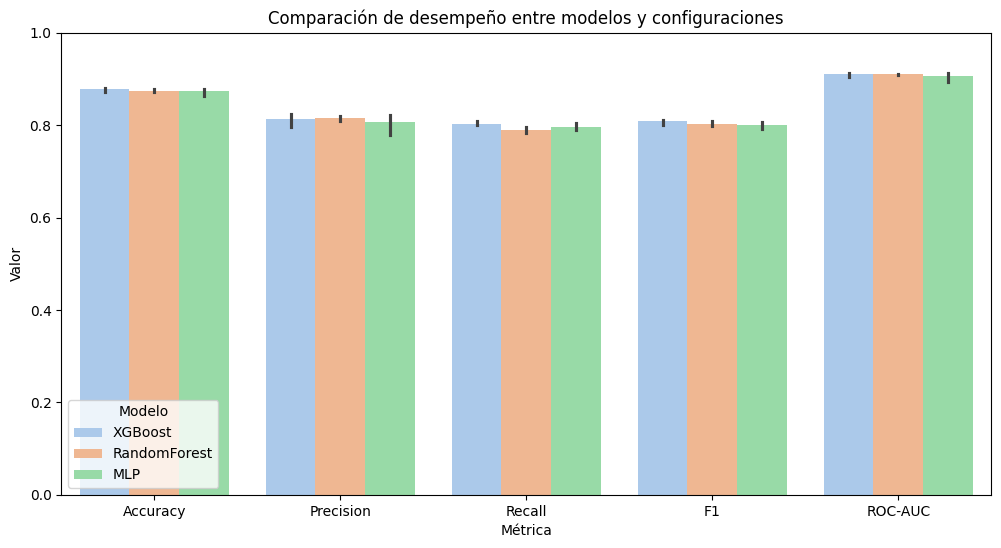


🏆 Mejores configuraciones por modelo:


,Modelo,Parámetros,Accuracy,Precision,Recall,F1,ROC-AUC
0,MLP,"{'hidden_layer_sizes': (50, 25), 'activation':...",0.877807,0.819444,0.794078,0.806562,0.912494
1,RandomForest,"{'n_estimators': 150, 'max_depth': 10, 'criter...",0.878670,0.819945,0.796770,0.808191,0.911204
2,XGBoost,"{'learning_rate': 0.05, 'max_depth': 3}",0.879965,0.815468,0.808883,0.812162,0.912754


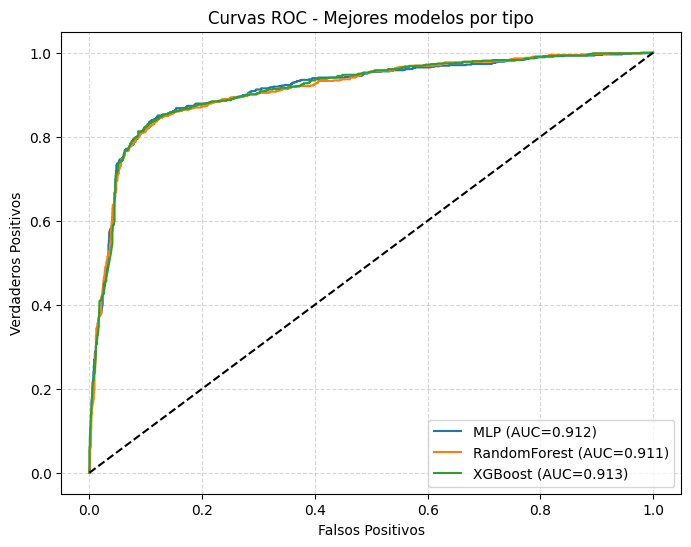


🏁 Ranking Final de Modelos (mejor configuración por tipo):


,Modelo,Parámetros,Accuracy,Precision,Recall,F1,ROC-AUC,Puntaje_Final
0,XGBoost,"{'learning_rate': 0.05, 'max_depth': 3}",0.879965,0.815468,0.808883,0.812162,0.912754,0.849237
1,RandomForest,"{'n_estimators': 150, 'max_depth': 10, 'criter...",0.878670,0.819945,0.796770,0.808191,0.911204,0.846480
2,MLP,"{'hidden_layer_sizes': (50, 25), 'activation':...",0.877807,0.819444,0.794078,0.806562,0.912494,0.845639


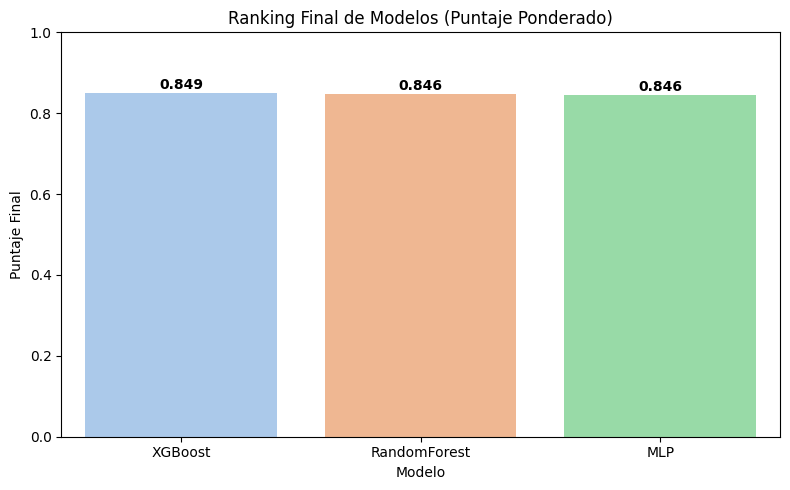

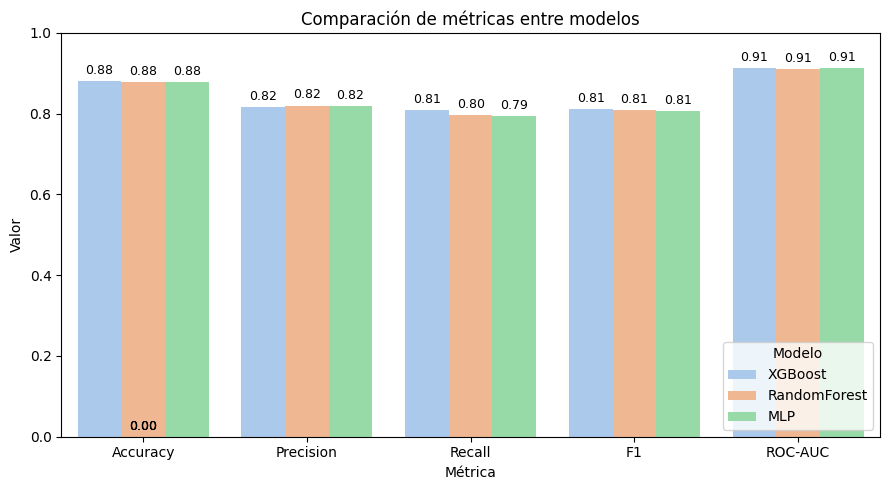

from matplotlib import pyplot as plt
ranking_final['Accuracy'].plot(kind='hist', bins=20, title='Accuracy')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
ranking_final['Precision'].plot(kind='hist', bins=20, title='Precision')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
ranking_final['Recall'].plot(kind='hist', bins=20, title='Recall')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
ranking_final['F1'].plot(kind='hist', bins=20, title='F1')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
import seaborn as sns
ranking_final.groupby('Modelo').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

...

from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(ranking_final['Parámetros'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(ranking_final, x='Accuracy', y='Parámetros', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

<string>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.



from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(ranking_final['Modelo'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(ranking_final, x='Precision', y='Modelo', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

<string>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.



from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(ranking_final['Parámetros'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(ranking_final, x='Precision', y='Parámetros', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

In [11]:
# ==============================================================
# 🔹 1. Importar librerías
# ==============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve
)

from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier

# ==============================================================
# 🔹 2. Cargar y preparar datos
# ==============================================================
df = pd.read_excel("base_para_ml.xlsx")

features = [
    'CALCULO1_NORMALIZADO', 'ECUACIONES_NORMALIZADO',
    'ESTADISTICA_NORMALIZADO', 'FÍSICA1_NORMALIZADO',
    'ALGEBRA_LINEAL_NORMALIZADO'
]
target = 'DESERTOR'

# Extraer año de cohorte
df['COHORTE'] = df['COHORTE'].astype(str)
df['AÑO_COHORTE'] = df['COHORTE'].str[:4].astype(int)

# Dividir datasets
train_df = df[df['AÑO_COHORTE'] <= 2018].dropna(subset=features + [target])
test_df = df[(df['AÑO_COHORTE'] >= 2019) & (df['AÑO_COHORTE'] <= 2022)].dropna(subset=features)

X_train = train_df[features]
y_train = train_df[target]
X_test = test_df[features]
y_test = test_df[target] if target in test_df.columns else None

# Escalar solo para MLP
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ==============================================================
# 🔹 3. Definir configuraciones de modelos
# ==============================================================
configuraciones = {
    "XGBoost": [
        {"learning_rate": 0.05, "max_depth": 3},
        {"learning_rate": 0.1, "max_depth": 4},
        {"learning_rate": 0.2, "max_depth": 6}
    ],
    "RandomForest": [
        {"n_estimators": 150, "max_depth": 10, "criterion": "gini"},
        {"n_estimators": 200, "max_depth": 15, "criterion": "gini"},
        {"n_estimators": 250, "max_depth": None, "criterion": "entropy"}
    ],
    "MLP": [
        {"hidden_layer_sizes": (50, 25), "activation": "relu"},
        {"hidden_layer_sizes": (100, 50), "activation": "relu"},
        {"hidden_layer_sizes": (150, 100, 50), "activation": "tanh"}
    ]
}

# ==============================================================
# 🔹 4. Entrenar y evaluar modelos
# ==============================================================
resultados = []
curvas_roc = {}  # Para guardar las curvas de los mejores modelos

for modelo_nombre, variantes in configuraciones.items():
    print(f"\n🚀 Entrenando variantes del modelo {modelo_nombre}...")

    for params in variantes:
        # Inicializar modelo según tipo
        if modelo_nombre == "XGBoost":
            modelo = XGBClassifier(
                objective='binary:logistic',
                eval_metric='logloss',
                random_state=42,
                n_estimators=150,
                **params
            )
            modelo.fit(X_train, y_train)
            y_pred = modelo.predict(X_test)
            y_proba = modelo.predict_proba(X_test)[:, 1]

        elif modelo_nombre == "RandomForest":
            modelo = RandomForestClassifier(random_state=42, **params)
            modelo.fit(X_train, y_train)
            y_pred = modelo.predict(X_test)
            y_proba = modelo.predict_proba(X_test)[:, 1]

        else:  # MLP
            modelo = MLPClassifier(
                solver='adam',
                max_iter=300,
                random_state=42,
                **params
            )
            modelo.fit(X_train_scaled, y_train)
            y_pred = modelo.predict(X_test_scaled)
            y_proba = modelo.predict_proba(X_test_scaled)[:, 1]

        # Calcular métricas
        acc = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred)
        rec = recall_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        roc = roc_auc_score(y_test, y_proba)

        resultados.append({
            "Modelo": modelo_nombre,
            "Parámetros": str(params),
            "Accuracy": acc,
            "Precision": prec,
            "Recall": rec,
            "F1": f1,
            "ROC-AUC": roc
        })

# ==============================================================
# 🔹 5. Comparar resultados
# ==============================================================
resultados_df = pd.DataFrame(resultados)
print("\n📊 Resultados comparativos:")
display(resultados_df.sort_values(by="ROC-AUC", ascending=False))

# ==============================================================
# 🔹 6. Visualización general
# ==============================================================
plt.figure(figsize=(12, 6))
resultados_melt = resultados_df.melt(id_vars=["Modelo", "Parámetros"],
                                     var_name="Métrica", value_name="Valor")
sns.barplot(data=resultados_melt, x="Métrica", y="Valor", hue="Modelo", palette="pastel")
plt.title("Comparación de desempeño entre modelos y configuraciones")
plt.ylim(0, 1)
plt.legend(title="Modelo")
plt.show()

# ==============================================================
# 🔹 7. Seleccionar los mejores modelos por tipo
# ==============================================================
mejores = resultados_df.loc[resultados_df.groupby("Modelo")["ROC-AUC"].idxmax()].reset_index(drop=True)
print("\n🏆 Mejores configuraciones por modelo:")
display(mejores)

# ==============================================================
# 🔹 8. Graficar curvas ROC de los tres mejores modelos
# ==============================================================
plt.figure(figsize=(8, 6))
for i, fila in mejores.iterrows():
    modelo_nombre = fila["Modelo"]
    params = eval(fila["Parámetros"])

    if modelo_nombre == "XGBoost":
        modelo = XGBClassifier(
            objective='binary:logistic',
            eval_metric='logloss',
            random_state=42,
            n_estimators=150,
            **params
        )
        modelo.fit(X_train, y_train)
        y_proba = modelo.predict_proba(X_test)[:, 1]

    elif modelo_nombre == "RandomForest":
        modelo = RandomForestClassifier(random_state=42, **params)
        modelo.fit(X_train, y_train)
        y_proba = modelo.predict_proba(X_test)[:, 1]

    else:  # MLP
        modelo = MLPClassifier(
            solver='adam',
            max_iter=300,
            random_state=42,
            **params
        )
        modelo.fit(X_train_scaled, y_train)
        y_proba = modelo.predict_proba(X_test_scaled)[:, 1]

    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, label=f"{modelo_nombre} (AUC={auc:.3f})")

plt.plot([0, 1], [0, 1], 'k--')
plt.title("Curvas ROC - Mejores modelos por tipo")
plt.xlabel("Falsos Positivos")
plt.ylabel("Verdaderos Positivos")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# ==============================================================
# 🔹 9. Ranking final de los tres mejores modelos
# ==============================================================

# Definir pesos para cada métrica
pesos = {
    "Accuracy": 0.25,
    "Precision": 0.2,
    "Recall": 0.2,
    "F1": 0.15,
    "ROC-AUC": 0.2
}

# Calcular puntaje ponderado total
mejores["Puntaje_Final"] = (
    mejores["Accuracy"] * pesos["Accuracy"] +
    mejores["Precision"] * pesos["Precision"] +
    mejores["Recall"] * pesos["Recall"] +
    mejores["F1"] * pesos["F1"] +
    mejores["ROC-AUC"] * pesos["ROC-AUC"]
)

# Ordenar por puntaje
ranking_final = mejores.sort_values(by="Puntaje_Final", ascending=False).reset_index(drop=True)

# Mostrar ranking en tabla
print("\n🏁 Ranking Final de Modelos (mejor configuración por tipo):")
display(ranking_final)

# ==============================================================
# 🔹 10. Visualización del ranking
# ==============================================================

plt.figure(figsize=(8, 5))
ax = sns.barplot(
    data=ranking_final,
    x="Modelo",
    y="Puntaje_Final",
    hue="Modelo",           # ✅ evita warning
    palette="pastel",
    legend=False
)

plt.title("Ranking Final de Modelos (Puntaje Ponderado)")
plt.ylim(0, 1)
plt.ylabel("Puntaje Final")
plt.xlabel("Modelo")

# Etiquetas sobre las barras
for i, v in enumerate(ranking_final["Puntaje_Final"]):
    plt.text(i, v + 0.01, f"{v:.3f}", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

# ==============================================================
# 🔹 11. Comparativa de métricas por modelo
# ==============================================================

# Transformar el dataframe a formato largo para graficar por métrica
metricas_long = ranking_final.melt(
    id_vars=["Modelo"],
    value_vars=["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"],
    var_name="Métrica",
    value_name="Valor"
)

plt.figure(figsize=(9, 5))
ax = sns.barplot(
    data=metricas_long,
    x="Métrica",
    y="Valor",
    hue="Modelo",
    palette="pastel"
)

plt.title("Comparación de métricas entre modelos")
plt.ylim(0, 1)
plt.ylabel("Valor")
plt.xlabel("Métrica")

# Etiquetas numéricas sobre las barras
for p in ax.patches:
    ax.annotate(
        f'{p.get_height():.2f}',
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center', va='bottom', fontsize=9, color='black', xytext=(0, 3),
        textcoords='offset points'
    )

plt.legend(title="Modelo")
plt.tight_layout()
plt.show()




🏁 Ranking Final de Modelos (mejor configuración por tipo):


,Modelo,Parámetros,Accuracy,Precision,Recall,F1,ROC-AUC,Puntaje_Final
0,XGBoost,"{'learning_rate': 0.05, 'max_depth': 3}",0.880,0.815,0.809,0.812,0.913,0.849
1,RandomForest,"{'n_estimators': 150, 'max_depth': 10, 'criterion': 'gini'}",0.879,0.820,0.797,0.808,0.911,0.846
2,MLP,"{'hidden_layer_sizes': (50, 25), 'activation': 'relu'}",0.878,0.819,0.794,0.807,0.912,0.846



📊 Resultados completos de todas las configuraciones evaluadas:


,Modelo,Parámetros,Accuracy,Precision,Recall,F1,ROC-AUC,Puntaje_Final
0,MLP,"{'hidden_layer_sizes': (50, 25), 'activation': 'relu'}",0.878,0.819,0.794,0.807,0.912,0.846
1,RandomForest,"{'n_estimators': 150, 'max_depth': 10, 'criterion': 'gini'}",0.879,0.820,0.797,0.808,0.911,0.846
2,XGBoost,"{'learning_rate': 0.05, 'max_depth': 3}",0.880,0.815,0.809,0.812,0.913,0.849


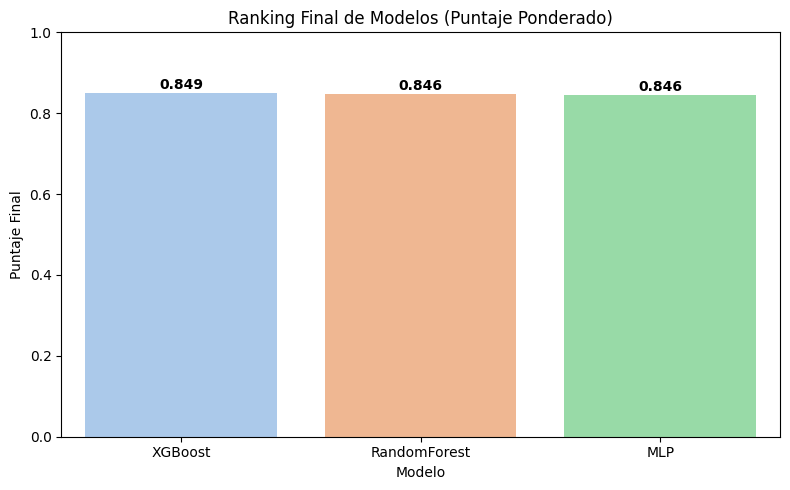

In [13]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ==============================================================
# 🧩 Configuración global de visualización
# ==============================================================

pd.set_option('display.max_colwidth', None)   # No truncar texto
pd.set_option('display.max_columns', None)    # Mostrar todas las columnas
pd.set_option('display.width', 2000)          # Evitar saltos de línea

# Paleta de colores personalizada para tablas
def estilo_tabla(df):
    return (
        df.style
        .background_gradient(subset=["Accuracy", "Precision", "Recall", "F1", "ROC-AUC", "Puntaje_Final"] if "Puntaje_Final" in df.columns else ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"], cmap="Blues")
        .set_properties(**{'text-align': 'center', 'white-space': 'normal'})
        .set_table_styles([
            {'selector': 'th', 'props': [('text-align', 'center'), ('background-color', '#DCE6F1')]},
            {'selector': 'td', 'props': [('padding', '6px 12px')]}
        ])
        .format(precision=3)
    )

# ==============================================================
# 🔹 9. Ranking final de los tres mejores modelos
# ==============================================================

# Definir pesos para cada métrica
pesos = {
    "Accuracy": 0.25,
    "Precision": 0.2,
    "Recall": 0.2,
    "F1": 0.15,
    "ROC-AUC": 0.2
}

# Calcular el puntaje ponderado
mejores["Puntaje_Final"] = (
    mejores["Accuracy"] * pesos["Accuracy"] +
    mejores["Precision"] * pesos["Precision"] +
    mejores["Recall"] * pesos["Recall"] +
    mejores["F1"] * pesos["F1"] +
    mejores["ROC-AUC"] * pesos["ROC-AUC"]
)

# Ordenar por puntaje total
ranking_final = mejores.sort_values(by="Puntaje_Final", ascending=False).reset_index(drop=True)

# ==============================================================
# 🔹 10. Mostrar resultados con estilo
# ==============================================================

print("\n🏁 Ranking Final de Modelos (mejor configuración por tipo):")
display(estilo_tabla(ranking_final))

# Si tienes un DataFrame intermedio 'mejores' (con todas las combinaciones evaluadas)
print("\n📊 Resultados completos de todas las configuraciones evaluadas:")
display(estilo_tabla(mejores))

# ==============================================================
# 🔹 11. Visualización del ranking
# ==============================================================

plt.figure(figsize=(8, 5))
ax = sns.barplot(
    data=ranking_final,
    x="Modelo",
    y="Puntaje_Final",
    hue="Modelo",
    palette="pastel",
    legend=False
)
plt.title("Ranking Final de Modelos (Puntaje Ponderado)")
plt.ylim(0, 1)
plt.ylabel("Puntaje Final")
plt.xlabel("Modelo")

# Etiquetas sobre las barras
for i, v in enumerate(ranking_final["Puntaje_Final"]):
    plt.text(i, v + 0.01, f"{v:.3f}", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()
